<a href="https://colab.research.google.com/github/kris743/python-ml/blob/main/Convolutional_Neural_Networks_for_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>









# Part 1: Convolutional Neural Network

###  Importing packages

In [10]:
import numpy as np
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras import backend as K
from keras.preprocessing import image
from keras.applications.mobilenet import MobileNet
from keras.applications.vgg16 import preprocess_input, decode_predictions
from keras.models import Model
import timeit

import warnings
warnings.filterwarnings('ignore')

### Preparing Dataset

In [11]:
batch_size = 128
num_classes = 10
epochs = 1

# input image dimensions
img_rows, img_cols = 28, 28

# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# type set to float
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


### Building a Model

In [12]:
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [13]:
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))

469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.0979 - loss: 2.3559 - val_accuracy: 0.1095 - val_loss: 2.3202


### Testing

In [14]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 2.320235013961792
Test accuracy: 0.10949999839067459


### Prediction

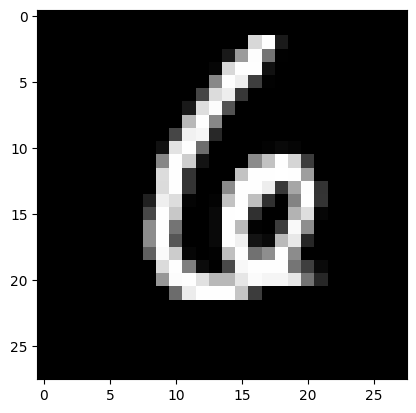

In [15]:
import pylab as plt

plt.imshow(x_test[123].reshape(28,28),cmap='gray')
plt.show()

In [16]:
import numpy as np
prediction = model.predict(x_test[123:124])
print('Prediction Score:\n',prediction[0])
thresholded = (prediction>0.5)*1
print('\nThresholded Score:\n',thresholded[0])
#print('\nPredicted Digit:\n',np.where(thresholded == 1)[1][0])

predicted_digit = np.argmax(prediction[0])
print(predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Prediction Score:
 [0.0982543  0.0895678  0.06971719 0.07784035 0.1112725  0.10524391
 0.1124666  0.07686834 0.12364221 0.13512678]

Thresholded Score:
 [0 0 0 0 0 0 0 0 0 0]
9


# Part 2: Applications of Convolutional Neural Network

###  MobileNet Models

In [17]:
model = MobileNet(input_shape=None, alpha=0.25, depth_multiplier=1, dropout=1e-3,
                                 include_top=True, weights='imagenet', input_tensor=None, pooling=None, classes=1000)

model.summary()

Model: "mobilenet_0.25_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 8)    │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 8)    │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 8)    │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 16)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 32)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │             

 Total params: 475,544 (1.81 MB)

 Trainable params: 470,072 (1.79 MB)

 Non-trainable params: 5,472 (21.38 KB)

###  Classify images

In [18]:
# Write the image name below

# You need to provide a valid path to an image file here.
# For example, if you upload an image named 'dog.jpg' to your Colab environment, use 'dog.jpg'.
# Or, you can use a URL to an image, if you download it first.
img_path = 'flower-729510_1280.jpg' # <--- REPLACE THIS WITH YOUR IMAGE PATH
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
print('Predicted:\n', decode_predictions(preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
Predicted:
 [[('n15075141', 'toilet_tissue', np.float32(0.09310233)), ('n03937543', 'pill_bottle', np.float32(0.08200853)), ('n03887697', 'paper_towel', np.float32(0.060797226)), ('n12144580', 'corn', np.float32(0.055406675)), ('n02948072', 'candle', np.float32(0.053852104))]]


After uploading, please update the `img_path` variable in the cell `qTFWBD9FkqKK` with the name of the file you just uploaded (e.g., `'flower-729510_1280.jpg'`) and then run that cell again.

###  Extract CNN features

In [19]:
features = model.predict(x)
print('\nFeature Shape:\n',features.shape)
print('\nFeatures:\n',features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Feature Shape:
 (1, 1000)

Features:
 [[1.00378756e-07 3.44803033e-04 5.97676831e-07 1.09887615e-07
  2.79236906e-06 1.28910949e-06 2.98420332e-06 1.93100423e-05
  5.22011669e-06 3.36188094e-07 2.05350812e-08 8.35293122e-06
  3.33778871e-06 2.94893141e-07 8.67806875e-07 4.88286923e-06
  9.27094106e-07 2.26485483e-07 4.06208812e-07 7.55936526e-07
  3.31881189e-09 3.27256839e-06 1.28226957e-05 4.94920778e-06
  1.51369077e-05 1.72519421e-07 2.80320328e-05 1.26428204e-04
  7.54270513e-06 2.38817011e-05 1.74674994e-08 5.05560138e-07
  4.44871290e-07 2.14217934e-07 1.99522242e-06 7.89022238e-07
  1.01677176e-06 8.04245246e-07 5.42080988e-06 1.07102078e-05
  1.11552008e-05 1.47228650e-06 4.42609189e-06 7.23896960e-07
  3.87510181e-06 4.43380159e-08 2.40837689e-05 3.95618445e-05
  1.14726362e-09 6.42273292e-08 1.15088824e-06 1.55125022e-07
  1.13068627e-05 1.81964948e-04 2.94242409e-06 1.74151974e-05
  5.43423175e-06 5.57601787e-08 1.34268603e-07 1.998647

###  Extract features from an arbitrary intermediate layer

In [21]:
model_minimal = Model(inputs=model.input, outputs=model.get_layer('conv_dw_2_relu').output)

conv_dw_2_relu_features = model_minimal.predict(x)
print('Features of conv_dw_2_relu:',conv_dw_2_relu_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
Features of conv_dw_2_relu: (1, 56, 56, 16)


### You can extract these features and use the base network as a feature extractor for your problems.

# Part 3: Deep Convolution Layer Visualization

In [22]:
import matplotlib as mp
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf

# from tensorflow.examples.tutorials.mnist import input_data # This is deprecated
import math

### Extract Data

In [23]:
# mnist = input_data.read_data_sets("MNIST_data/", one_hot=True) # This is deprecated
(x_train_vis, y_train_vis), (x_test_vis, y_test_vis) = tf.keras.datasets.mnist.load_data()

x_train_vis = x_train_vis.astype('float32') / 255.
x_test_vis = x_test_vis.astype('float32') / 255.

y_train_vis = tf.keras.utils.to_categorical(y_train_vis, 10)
y_test_vis = tf.keras.utils.to_categorical(y_test_vis, 10)

class MNISTData:
    def __init__(self, images, labels):
        self.images = images.reshape(-1, 784)
        self.labels = labels
        self.num_examples = images.shape[0]
        self.epochs_completed = 0
        self._index_in_epoch = 0

    def next_batch(self, batch_size):
        start = self._index_in_epoch
        self._index_in_epoch += batch_size
        if self._index_in_epoch > self.num_examples:
            self.epochs_completed += 1
            perm = np.arange(self.num_examples)
            np.random.shuffle(perm)
            self.images = self.images[perm]
            self.labels = self.labels[perm]
            start = 0
            self._index_in_epoch = batch_size
            assert batch_size <= self.num_examples
        end = self._index_in_epoch
        return self.images[start:end], self.labels[start:end]

mnist = type('obj', (object,), {
    'train': MNISTData(x_train_vis, y_train_vis),
    'test': MNISTData(x_test_vis, y_test_vis)
})()

In [24]:
# The previous attempt to install TensorFlow 1.15 failed, as it's no longer available.
# We will proceed by refactoring the code to TensorFlow 2.x using Keras.

# The previous cell failed to install TensorFlow 1.15.
# The notebook will now be refactored to use TensorFlow 2.x with Keras for this section.

### Model Building

In [27]:
tf.keras.backend.clear_session()

x_image_input = tf.keras.layers.Input(shape=(28, 28, 1), name='x-in')

# Original model architecture using Keras layers
hidden_1 = tf.keras.layers.Conv2D(5, (5, 5), activation='relu', padding='same')(x_image_input)
pool_1 = tf.keras.layers.MaxPooling2D((2, 2))(hidden_1)
hidden_2 = tf.keras.layers.Conv2D(5, (5, 5), activation='relu', padding='same')(pool_1)
pool_2 = tf.keras.layers.MaxPooling2D((2, 2))(hidden_2)
hidden_3 = tf.keras.layers.Conv2D(20, (5, 5), activation='relu', padding='same')(pool_2)
hidden_3_dropout = tf.keras.layers.Dropout(0.5)(hidden_3)
flatten = tf.keras.layers.Flatten()(hidden_3_dropout)
out_y = tf.keras.layers.Dense(10, activation='softmax')(flatten)

model_part3 = tf.keras.Model(inputs=x_image_input, outputs=out_y)

model_part3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_part3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ x-in (InputLayer)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 5)      │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 5)      │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 980)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         9,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,090 (51.13 KB)

 Trainable params: 13,090 (51.13 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [29]:
batchSize = 50
epochs_part3 = 1 # Reduced epochs for demonstration, can be increased if needed

# Reshape x_train_vis and x_test_vis for the Keras model
x_train_reshaped = x_train_vis.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_vis.reshape(-1, 28, 28, 1)

history = model_part3.fit(x_train_reshaped, y_train_vis,
                          batch_size=batchSize,
                          epochs=epochs_part3,
                          verbose=1,
                          validation_data=(x_test_reshaped, y_test_vis))


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.9152 - loss: 0.2732 - val_accuracy: 0.9476 - val_loss: 0.1768


### Testing accuracy

In [ ]:
test_loss, test_accuracy = model_part3.evaluate(x_test_reshaped, y_test_vis, verbose=0)
print("Test loss: %g" % test_loss)
print("Test accuracy: %g" % test_accuracy)

### Get activation values and plotting

In [ ]:
def getActivations(layer_name, stimuli):
    # Create a Keras model that outputs the activation of the specified layer
    intermediate_layer_model = tf.keras.Model(inputs=model_part3.input,
                                              outputs=model_part3.get_layer(layer_name).output)

    # Reshape stimuli for model input
    stimuli_reshaped = np.reshape(stimuli, [1, 28, 28, 1])
    units = intermediate_layer_model.predict(stimuli_reshaped)
    plotNNFilter(units)

def plotNNFilter(units):
    filters = units.shape[-1] # Last dimension is the number of filters
    plt.figure(1, figsize=(20,20))
    n_columns = 6
    n_rows = math.ceil(filters / n_columns) + 1
    for i in range(filters):
        plt.subplot(n_rows, n_columns, i+1)
        plt.title('Filter ' + str(i))
        # Adjust imshow for activations which might not be 2D
        # Assuming activations are 4D (batch, height, width, channels)
        plt.imshow(units[0,:,:,i], interpolation="nearest", cmap="gray")

### Input Image

In [ ]:
imageToUse = mnist.test.images[0]
plt.imshow(np.reshape(imageToUse,[28,28]), interpolation="nearest", cmap="gray")
plt.show()

### Activation in Layer 1 (Conv2D layer, index 0)

In [ ]:
getActivations(model_part3.layers[0].name, imageToUse)

### Activation in Layer 2 (Conv2D layer, index 2)

In [ ]:
getActivations(model_part3.layers[2].name, imageToUse)

### Activation in Layer 3 (Conv2D layer, index 4)

In [ ]:
getActivations(model_part3.layers[4].name, imageToUse)

# Part 4: Design Choices in Convolutional Neural Networks

## Influence of convolution size

### Model with (3 x 3) Convolution

In [ ]:
K.clear_session()
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       294,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,522 (1.13 MB)

 Trainable params: 296,522 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

283/469 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.1226 - loss: 2.2866

### Model with (7 x 7) Convolution

In [ ]:
# Write your code here

# Use the same model design from the above cell

## Striding

### Model with (7 x 7) Convolution with 2 Steps

In [ ]:
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(7, 7), strides=2, activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (7, 7), strides=2, activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

## Padding

### Model with (7 x 7) Convolution with Same Padding

In [32]:
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(7, 7), strides=1, padding='same', activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (7, 7), strides=1, padding='same', activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 8)      │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │         6,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       401,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,458 (1.56 MB)

 Trainable params: 408,458 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 164s 343ms/step - accuracy: 0.2686 - loss: 2.2774 - val_accuracy: 0.3829 - val_loss: 2.2535
Time Taken to run the model: 166.033740501 seconds


## Pooling

### Model with (3 x 3) Convolution with Pooling (2 x 2)

In [34]:
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1646 - loss: 2.2809 - val_accuracy: 0.1839 - val_loss: 2.2737
Time Taken to run the model: 21.487095344999943 seconds


### Model with (3 x 3) Convolution with Pooling (3 x 3)

In [ ]:
# Write your code here

# Use the same model design from the above cell

### What are your findings?